<a href="https://colab.research.google.com/github/2536212018-a11y/proyecto-bi-prestige/blob/main/Proyecto_BI_Prestige.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/2536212018-a11y/proyecto-bi-prestige/refs/heads/main/data/Prestige_modificado.cs/Prestige_modificado.csv"

df = pd.read_csv(url, sep=';')

df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [3]:
# Revisar cantidad de filas y columnas

df.shape

(102, 7)

In [4]:
# Revisar nombres de columnas

df.columns

Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')

In [5]:
# Revisar tipos de datos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB


In [6]:
# Revisar valores nulos

df.isnull().sum()

,0
occupation,0
education,0
income,0
women,0
prestige,0
census,0
type_num,0


In [8]:
# Revisar registros duplicados

df.duplicated().sum()

np.int64(0)

In [9]:
# Estadistica descriptiva

df.describe()

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


In [10]:
# Seleccionar variables numericas

variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# Crear matriz de correlacion

matriz_correlacion = variables_numericas.corr()

# Mostrar matriz

matriz_correlacion.round(3)

,education,income,women,prestige,census,type_num
education,1.000,0.578,0.062,0.850,-0.823,-0.382
income,0.578,1.000,-0.441,0.715,-0.361,-0.368
women,0.062,-0.441,1.000,-0.118,-0.227,0.251
prestige,0.850,0.715,-0.118,1.000,-0.635,-0.465
census,-0.823,-0.361,-0.227,-0.635,1.000,0.288
type_num,-0.382,-0.368,0.251,-0.465,0.288,1.000


In [11]:
# Correlaciones con prestige

matriz_correlacion['prestige'].sort_values(ascending=False)

,prestige
prestige,1.000000
education,0.850177
income,0.714906
women,-0.118334
type_num,-0.464762
census,-0.634510


In [15]:
import matplotlib.pyplot as plt

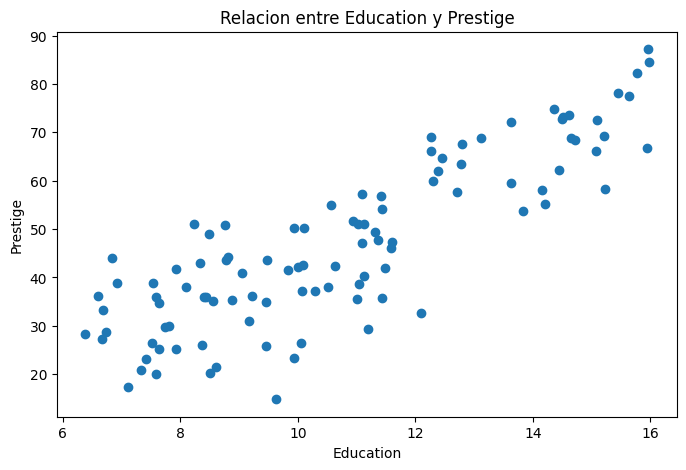

In [16]:
# Grafica Education vs Prestige

plt.figure(figsize=(8,5))

plt.scatter(df['education'], df['prestige'])

plt.xlabel('Education')
plt.ylabel('Prestige')

plt.title('Relacion entre Education y Prestige')

plt.show()

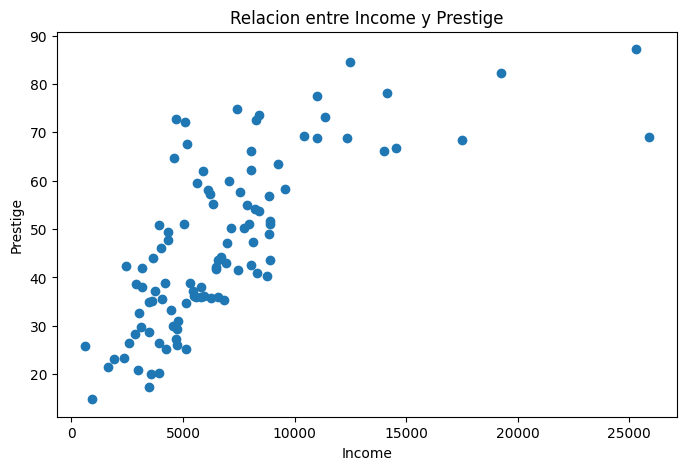

In [17]:
# Grafica Income vs Prestige

plt.figure(figsize=(8,5))

plt.scatter(df['income'], df['prestige'])

plt.xlabel('Income')
plt.ylabel('Prestige')

plt.title('Relacion entre Income y Prestige')

plt.show()

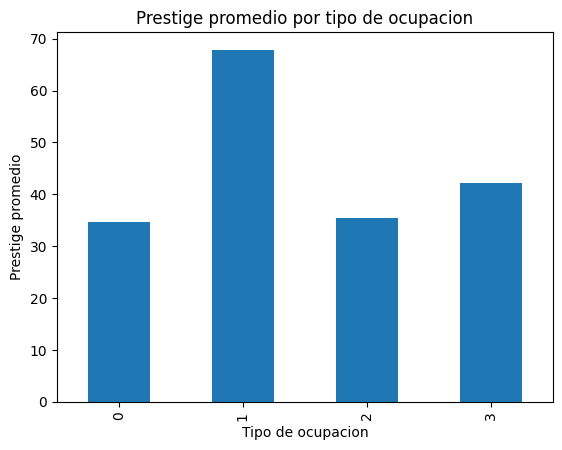

In [19]:
# Prestige promedio por tipo

df.groupby('type_num')['prestige'].mean().plot(kind='bar')

plt.xlabel('Tipo de ocupacion')
plt.ylabel('Prestige promedio')

plt.title('Prestige promedio por tipo de ocupacion')

plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [22]:
# Variables para clusterizacion

X = df[['education', 'income', 'women', 'prestige']]

In [23]:
# Escalar datos

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
# Modelo K-Means con 4 clusters

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster4'] = kmeans4.fit_predict(X_scaled)

In [25]:
# Cantidad de registros por cluster

df['Cluster4'].value_counts()

,count
Cluster4,
0,42
3,26
2,22
1,12


In [26]:
# Promedio de variables por cluster

df.groupby('Cluster4')[['education','income','women','prestige']].mean()

,education,income,women,prestige
Cluster4,,,,
0,8.522143,5599.023810,9.767619,35.171429
1,14.685833,15746.833333,6.005000,74.233333
2,10.047273,3395.954545,76.658636,37.727273
3,13.080000,7482.846154,30.271923,60.730769


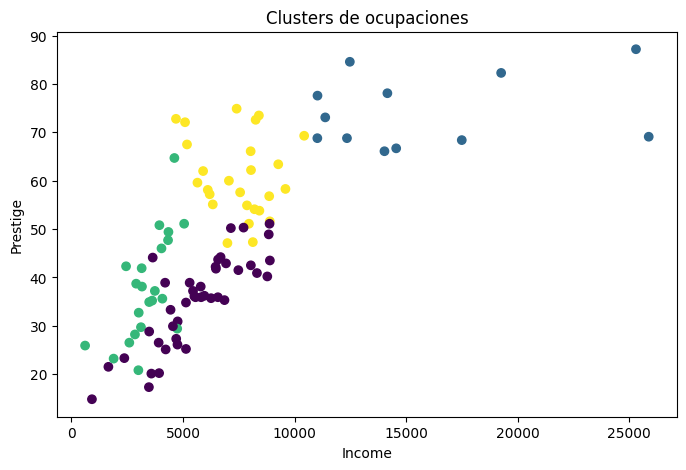

In [27]:
# Visualizacion de clusters

plt.figure(figsize=(8,5))

plt.scatter(df['income'], df['prestige'], c=df['Cluster4'])

plt.xlabel('Income')
plt.ylabel('Prestige')

plt.title('Clusters de ocupaciones')

plt.show()

In [28]:
# Modelo K-Means con 5 clusters

kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster5'] = kmeans5.fit_predict(X_scaled)

In [29]:
# Cantidad de registros por cluster

df['Cluster5'].value_counts()

,count
Cluster5,
4,28
1,27
0,21
2,13
3,13


In [30]:
# Centroides de K=5

df.groupby('Cluster5')[['education','income','women','prestige']].mean()

,education,income,women,prestige
Cluster5,,,,
0,9.932381,3337.952381,75.731905,36.442857
1,10.697037,7661.444444,9.275926,49.222222
2,14.726154,15338.000000,7.443846,73.853846
3,14.166154,6723.846154,53.786154,65.961538
4,7.938571,4629.500000,11.394643,30.896429


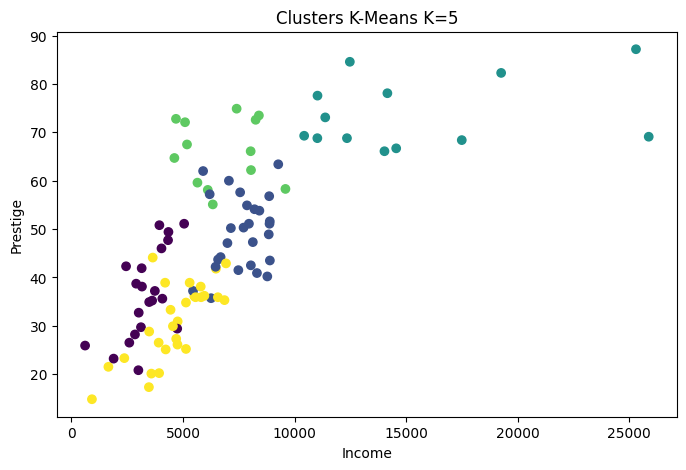

In [31]:
# Visualizacion clusters K=5

plt.figure(figsize=(8,5))

plt.scatter(df['income'], df['prestige'], c=df['Cluster5'])

plt.xlabel('Income')
plt.ylabel('Prestige')

plt.title('Clusters K-Means K=5')

plt.show()